In [28]:
import numpy as np
import pandas as pd

In [29]:
model_df = pd.read_csv('team_stats_model_ready.csv')

In [45]:

# final feature set
final_features = [
    "off_pass_Y/A",
    "off_pass_Int%",
    "def_pass_PD",
    "off_rush_Y/A",
    "def_rush_TD%",
    "def_Fmb%",
    "def_adv_Prss%"   # swap to def_adv_Hrry% if that's your final choice
]

In [46]:
X = model_df.drop(columns=["season", "team", "made_playoffs"])
y = model_df["made_playoffs"]

X

,off_pass_Y/A,off_pass_Int%,def_pass_PD,off_rush_Y/A,def_rush_TD%,def_Fmb%,def_adv_Prss%
0,7.7,1.9,67,4.3,0.019074,0.009980,0.232
1,7.3,2.9,59,4.7,0.035052,0.006836,0.258
2,6.2,4.6,73,4.2,0.038636,0.011364,0.280
3,6.5,3.6,76,4.0,0.036364,0.006598,0.241
4,6.7,1.6,89,4.5,0.031073,0.005133,0.289
...,...,...,...,...,...,...,...
251,6.8,2.0,79,3.7,0.023211,0.009497,0.247
252,8.4,3.1,96,4.1,0.021531,0.006573,0.261
253,7.9,1.3,82,4.6,0.018349,0.009328,0.263
254,7.5,2.8,56,3.8,0.030660,0.009728,0.167


## Logisitc Regression

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1818
)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
y_pred = log_model.predict(X_test_scaled)

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8269230769230769

Confusion Matrix
[[29  2]
 [ 7 14]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        31
           1       0.88      0.67      0.76        21

    accuracy                           0.83        52
   macro avg       0.84      0.80      0.81        52
weighted avg       0.83      0.83      0.82        52



In [36]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)

         Feature  Coefficient
0   off_pass_Y/A     0.820762
2    def_pass_PD     0.650014
5       def_Fmb%     0.519852
6  def_adv_Prss%     0.519850
3   off_rush_Y/A     0.296589
4   def_rush_TD%    -0.443058
1  off_pass_Int%    -0.888267


In [37]:
results = model_df.loc[X_test.index, ["season", "team"]].copy()
results["actual"] = y_test
results["predicted"] = y_pred

print(results)

     season                  team  actual  predicted
186    2023       Atlanta Falcons       0          0
145    2022        Dallas Cowboys       1          0
66     2020  New England Patriots       0          0
40     2019        Houston Texans       1          0
119    2021      Baltimore Ravens       0          0
96     2021        Dallas Cowboys       1          1
123    2021  Jacksonville Jaguars       0          0
131    2022         New York Jets       0          0
106    2021       Atlanta Falcons       0          0
231    2025      Cleveland Browns       0          0
2      2018         Buffalo Bills       0          0
122    2021        Houston Texans       0          0
249    2025  Tampa Bay Buccaneers       0          0
103    2021         Detroit Lions       0          0
195    2024  New England Patriots       0          0
130    2022  New England Patriots       0          1
1      2018        Miami Dolphins       0          0
180    2023         Detroit Lions       1     

In [38]:
print(model_df["season"].unique())

[2018 2019 2020 2021 2022 2023 2024 2025]


In [39]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

kf = KFold(n_splits=5, shuffle=False)

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X, y, cv=kf)

print("Fold Accuracies:", scores)
print("Average Accuracy:", scores.mean())

Fold Accuracies: [0.84615385 0.76470588 0.70588235 0.76470588 0.7254902 ]
Average Accuracy: 0.7613876319758673


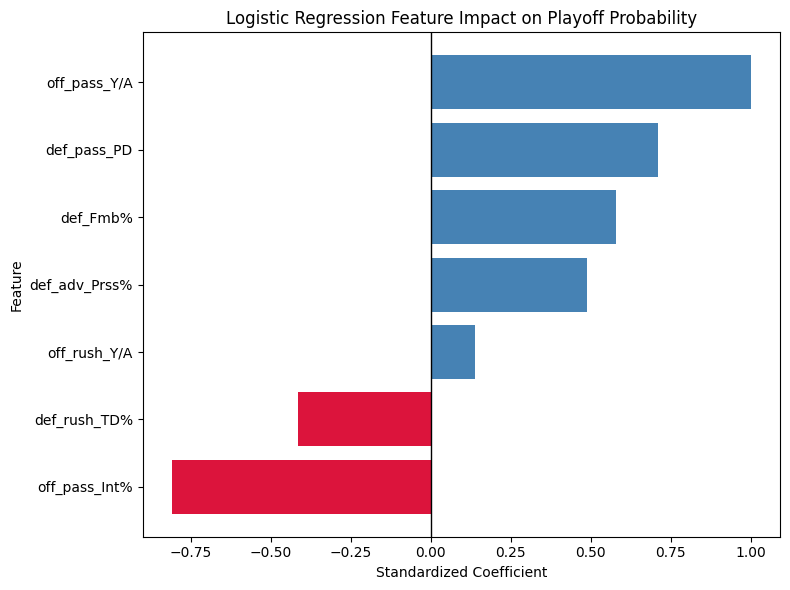

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale (important for interpretable coefficients)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit model
log_model = LogisticRegression()
log_model.fit(X_scaled, y)

# Build coefficient dataframe
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient")

# Plot
plt.figure(figsize=(8,6))
colors = ["crimson" if x < 0 else "steelblue" for x in coef_df["Coefficient"]]

plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title("Logistic Regression Feature Impact on Playoff Probability")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=2120
)

scores = cross_val_score(rf, X, y, cv=kf)

print("RF Fold Accuracies:", scores)
print("RF Average Accuracy:", scores.mean())

RF Fold Accuracies: [0.78846154 0.70588235 0.70588235 0.78431373 0.78431373]
RF Average Accuracy: 0.7537707390648567


In [42]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 5-fold CV
kf = KFold(n_splits=5, shuffle=False)

fold_accuracies = []
all_y_true = []
all_y_pred = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # scale within fold
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # logistic model
    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train_scaled, y_train)

    # predict
    y_pred = log_model.predict(X_test_scaled)

    # store fold accuracy
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    # store for overall confusion matrix / report
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

# results
print("Logistic Fold Accuracies:", fold_accuracies)
print("Logistic Average Accuracy:", round(np.mean(fold_accuracies), 3))
print("Logistic Std Dev:", round(np.std(fold_accuracies), 3))

print("\nLogistic Confusion Matrix:")
print(confusion_matrix(all_y_true, all_y_pred))

print("\nLogistic Classification Report:")
print(classification_report(all_y_true, all_y_pred))

Logistic Fold Accuracies: [0.7692307692307693, 0.7843137254901961, 0.6862745098039216, 0.803921568627451, 0.8431372549019608]
Logistic Average Accuracy: 0.777
Logistic Std Dev: 0.052

Logistic Confusion Matrix:
[[119  29]
 [ 28  80]]

Logistic Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       148
           1       0.73      0.74      0.74       108

    accuracy                           0.78       256
   macro avg       0.77      0.77      0.77       256
weighted avg       0.78      0.78      0.78       256



In [43]:
df = model_df.copy()
df = df.sort_values(["team", "season"])

In [47]:
for col in final_features:
    df[f"{col}_roll3"] = (
        df.groupby("team")[col]
        .rolling(window=3)
        .mean()
        .reset_index(level=0, drop=True)
    )

In [48]:
df["target_next_year"] = df.groupby("team")["made_playoffs"].shift(-1)

In [49]:
df_model = df.dropna(subset=[f"{col}_roll3" for col in final_features] + ["target_next_year"])

In [50]:
X = df_model[[f"{col}_roll3" for col in final_features]]
y = df_model["target_next_year"]

In [51]:
results = []
predictions = []

seasons = sorted(df_model["season"].unique())

for year in seasons[:-1]:
    
    train_df = df_model[df_model["season"] < year]
    test_df = df_model[df_model["season"] == year]
    
    if len(train_df) < 50:
        continue  # skip early years
    
    X_train = train_df[[f"{col}_roll3" for col in final_features]]
    y_train = train_df["target_next_year"]
    
    X_test = test_df[[f"{col}_roll3" for col in final_features]]
    y_test = test_df["target_next_year"]
    
    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    
    results.append({
        "test_year": year,
        "accuracy": acc
    })
    
    temp = test_df[["team", "season"]].copy()
    temp["predicted_playoff"] = preds
    temp["playoff_probability"] = probs
    temp["actual"] = y_test.values
    
    predictions.append(temp)

In [52]:
results_df = pd.DataFrame(results)

print(results_df)
print("\nAverage Accuracy:", round(results_df["accuracy"].mean(), 3))
print("Std Dev:", round(results_df["accuracy"].std(), 3))

   test_year  accuracy
0       2022   0.65625
1       2023   0.65625

Average Accuracy: 0.656
Std Dev: 0.0


In [53]:
latest_df = df[df["season"] == 2025].copy()

In [54]:
X_2026 = latest_df[[f"{col}_roll3" for col in final_features]]

In [55]:
train_df = df_model.copy()

X_train = train_df[[f"{col}_roll3" for col in final_features]]
y_train = train_df["target_next_year"]

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_2026 = scaler.transform(X_2026)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [57]:
probs_2026 = model.predict_proba(X_2026)[:, 1]
preds_2026 = model.predict(X_2026)

In [58]:
pred_2026 = latest_df[["team"]].copy()

pred_2026["playoff_probability"] = probs_2026
pred_2026["predicted_playoff"] = preds_2026

pred_2026 = pred_2026.sort_values("playoff_probability", ascending=False)

print(pred_2026.head(20))

                     team  playoff_probability  predicted_playoff
245     Green Bay Packers             0.641927                1.0
228   Pittsburgh Steelers             0.608276                1.0
225         Buffalo Bills             0.595908                1.0
241        Dallas Cowboys             0.589406                1.0
233        Houston Texans             0.566622                1.0
247         Detroit Lions             0.563698                1.0
236        Denver Broncos             0.531186                1.0
229      Baltimore Ravens             0.520715                1.0
253      Los Angeles Rams             0.513282                1.0
240   Philadelphia Eagles             0.501594                1.0
249  Tampa Bay Buccaneers             0.492842                0.0
237  Los Angeles Chargers             0.477469                0.0
244         Chicago Bears             0.463411                0.0
238    Kansas City Chiefs             0.451465                0.0
230    Cin

In [59]:
pred_2026.head(14)

,team,playoff_probability,predicted_playoff
245,Green Bay Packers,0.641927,1.0
228,Pittsburgh Steelers,0.608276,1.0
225,Buffalo Bills,0.595908,1.0
241,Dallas Cowboys,0.589406,1.0
233,Houston Texans,0.566622,1.0
247,Detroit Lions,0.563698,1.0
236,Denver Broncos,0.531186,1.0
229,Baltimore Ravens,0.520715,1.0
253,Los Angeles Rams,0.513282,1.0
240,Philadelphia Eagles,0.501594,1.0
